# Chapter 5. 양자 신경망 분류기와 회귀기

## Neural Network Classifier & Regressor

이 튜토리얼에서는 `NeuralNetworkClassifier`와 `NeuralNetworkRegressor`를 사용하는 방법을 보여준다(demonstrate).
둘 다 (Quantum) `NeuralNetwork`를 입력으로 받고 특정 맥락(context)에서 그것을 활용한다(leverage).
두 경우 모두 편의상 사전 구성된 변형(variant)을 제공하는데, 이는 변분 양자 분류기(`VQC`)와 변분 양자 회귀기(`VQR`)이다. 튜토리얼은 다음과 같이 구성된다:

1. [분류(Classification)](#Classification) 
    * `EstimatorQNN`을 이용한 분류
    * `SamplerQNN`을 이용한 분류
    * 변분 양자 분류기(`VQC`)
    
2. [회귀(Regression)](#Regression)
    * `EstimatorQNN`을 이용한 회귀
    * 변분 양자 회귀기(`VQR`)

In [1]:
# 시각화(Visualization), 수치 연산(NumPy), 양자 회로(Quantum Circuit) 관련 라이브러리 임포트
# 분류기(Classifier), 회귀기(Regressor), 양자 신경망(QNN) 클래스 임포트
# 재현성(Reproducibility)을 위한 랜덤 시드(Random Seed) 설정
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.circuit.library import real_amplitudes, zz_feature_map
from qiskit_machine_learning.optimizers import COBYLA, L_BFGS_B
from qiskit_machine_learning.utils import algorithm_globals

from qiskit_machine_learning.algorithms.classifiers import NeuralNetworkClassifier, VQC
from qiskit_machine_learning.algorithms.regressors import NeuralNetworkRegressor, VQR
from qiskit_machine_learning.neural_networks import SamplerQNN, EstimatorQNN
from qiskit_machine_learning.circuit.library import qnn_circuit

algorithm_globals.random_seed = 42

## 분류(Classification)

간단한 분류 데이터셋(dataset)을 준비하여 다음 알고리즘들을 설명한다.

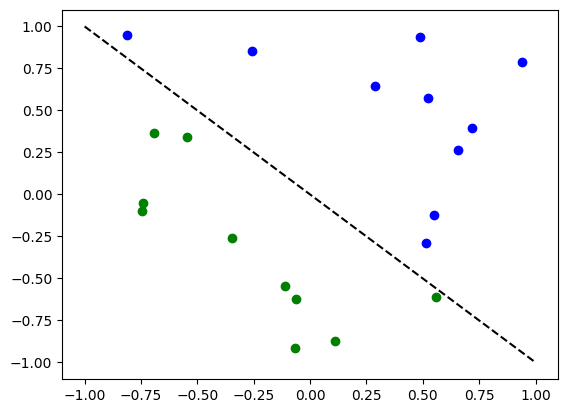

In [2]:
# 2차원 입력(Input), 20개 샘플(Sample)의 간단한 분류 데이터셋(Dataset) 생성
# y01: {0, 1} 이진 레이블(Binary Label), y: {-1, +1} 레이블(EstimatorQNN용)
# y_one_hot: 원-핫 인코딩(One-Hot Encoding) 레이블(VQC용)
num_inputs = 2
num_samples = 20
X = 2 * algorithm_globals.random.random([num_samples, num_inputs]) - 1
y01 = 1 * (np.sum(X, axis=1) >= 0)  # in { 0,  1}
y = 2 * y01 - 1  # in {-1, +1}
y_one_hot = np.zeros((num_samples, 2))
for i in range(num_samples):
    y_one_hot[i, y01[i]] = 1

for x, y_target in zip(X, y):
    if y_target == 1:
        plt.plot(x[0], x[1], "bo")
    else:
        plt.plot(x[0], x[1], "go")
plt.plot([-1, 1], [1, -1], "--", color="black")
plt.show()

### EstimatorQNN을 이용한 분류

먼저 `EstimatorQNN`을 `NeuralNetworkClassifier` 내에서 분류에 사용하는 방법을 보여준다. 이 맥락(context)에서 `EstimatorQNN`은 $[-1, +1]$ 범위의 1차원 출력을 반환해야 한다. 이는 이진 분류에만 작동하고 두 클래스(class)를 $\{-1, +1\}$에 할당한다. 특성 맵(feature map)과 안자츠(ansatz)로부터 매개변수화된 양자 회로(quantum circuit)를 간단하게 구성하려면 `qnn_circuit`을 사용할 수 있다.

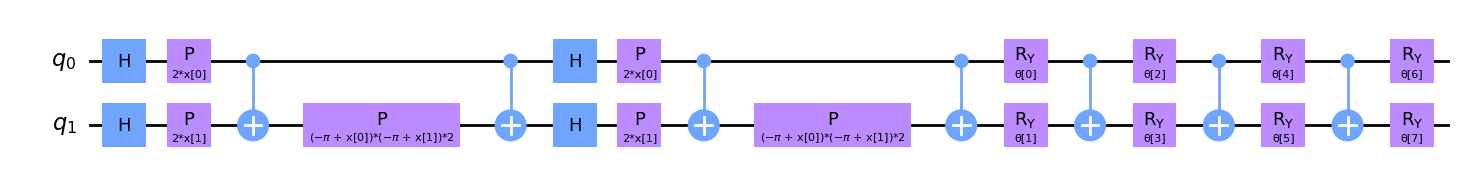

In [3]:
# 기본 ZZ 특성 맵(ZZ Feature Map)과 실진폭 안자츠(RealAmplitudes Ansatz)로 QNN 회로(Circuit) 구성
# construct QNN with the qnn_circuit's default zz_feature_map feature map and real_amplitudes ansatz.
qc, fm_params, anz_params = qnn_circuit(num_qubits=2)
qc.draw("mpl", style="clifford")

양자 신경망(quantum neural network)을 생성한다. 우리는 국소 상태 벡터(local statevector) 시뮬레이션을 수행하고 있으므로 `qiskit.primitives.StatevectorEstimator`에서 `estimator` 매개변수를 설정한다.

In [4]:
# 상태 벡터 추정기(StatevectorEstimator) 생성 및 EstimatorQNN 인스턴스화
from qiskit.primitives import StatevectorEstimator as Estimator

estimator = Estimator()
estimator_qnn = EstimatorQNN(
    circuit=qc, input_params=fm_params, weight_params=anz_params, estimator=estimator
)

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


In [5]:
# QNN은 입력(Input)을 [-1, +1] 범위로 매핑(Mapping)한다
# 첫 번째 샘플(Sample)과 랜덤 가중치(Weight)로 순전파(Forward Pass) 테스트
# QNN maps inputs to [-1, +1]
estimator_qnn.forward(X[0, :], algorithm_globals.random.random(estimator_qnn.num_weights))

array([[0.24939731]])

`callback_graph`라는 콜백 함수(callback function)를 추가한다. 이 함수는 최적화기(optimizer)의 각 반복(iteration)에서 호출되며 두 개의 매개변수를 전달받는다: 현재 가중치(weights)와 그 가중치에서의 목적 함수(objective function) 값. 우리 함수의 경우 목적 함수의 값을 배열에 추가하므로 반복 횟수 대 목적 함수 값의 그래프를 그릴 수 있고 각 반복마다 그래프를 업데이트한다. 그러나 두 개의 앞서 언급한 매개변수를 전달받으면 콜백 함수로 무엇이든 할 수 있다.

In [6]:
# 학습 과정에서 목적 함수(Objective Function) 값을 실시간 시각화하는 콜백 함수(Callback Function)
# callback function that draws a live plot when the .fit() method is called
def callback_graph(weights, obj_func_eval):
    clear_output(wait=True)
    objective_func_vals.append(obj_func_eval)
    plt.title("Objective function value against iteration")
    plt.xlabel("Iteration")
    plt.ylabel("Objective function value")
    plt.plot(range(len(objective_func_vals)), objective_func_vals)
    plt.show()

In [7]:
# EstimatorQNN 기반 신경망 분류기(Neural Network Classifier) 구성
# COBYLA 최적화기(Optimizer), 최대 반복 횟수(Max Iterations) = 60
# construct neural network classifier
estimator_classifier = NeuralNetworkClassifier(
    estimator_qnn, optimizer=COBYLA(maxiter=60), callback=callback_graph
)

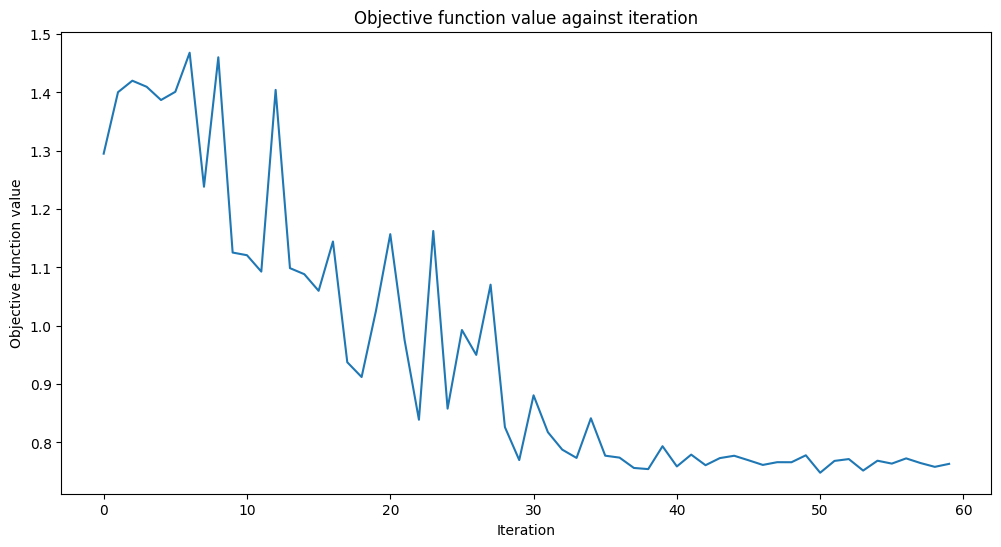

0.75

In [8]:
# 목적 함수(Objective Function) 값 히스토리(History) 초기화
# 분류기(Classifier)를 데이터에 학습(Fitting)
# 분류기(Classifier) 정확도(Accuracy) 평가
# create empty array for callback to store evaluations of the objective function
objective_func_vals = []
plt.rcParams["figure.figsize"] = (12, 6)

# fit classifier to data
estimator_classifier.fit(X, y)

# return to default figsize
plt.rcParams["figure.figsize"] = (6, 4)

# score classifier
estimator_classifier.score(X, y)

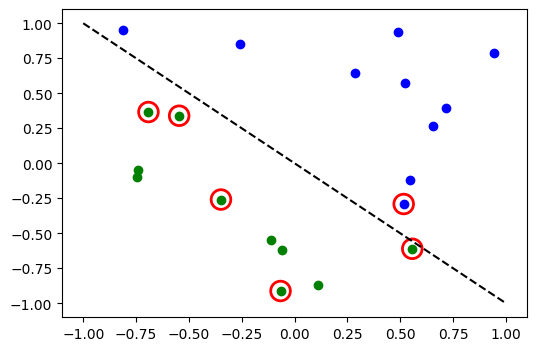

In [9]:
# 예측(Prediction) 수행 및 결과 시각화(Visualization)
# 빨간색 원 = 오분류(Misclassified)된 샘플(Sample)
# evaluate data points
y_predict = estimator_classifier.predict(X)

# plot results
# red == wrongly classified
for x, y_target, y_p in zip(X, y, y_predict):
    if y_target == 1:
        plt.plot(x[0], x[1], "bo")
    else:
        plt.plot(x[0], x[1], "go")
    if y_target != y_p:
        plt.scatter(x[0], x[1], s=200, facecolors="none", edgecolors="r", linewidths=2)
plt.plot([-1, 1], [1, -1], "--", color="black")
plt.show()

이제 모델이 학습(trained)되었으므로 신경망(neural network)의 가중치(weights)를 탐색할 수 있다. 가중치의 개수는 안자츠(ansatz)로 정의된다는 점에 유의한다.

In [10]:
# 학습된 신경망(Neural Network)의 가중치(Weight) 확인
estimator_classifier.weights

array([ 0.96348819,  0.52841822, -1.03993002,  0.22359173,  0.89095648,
       -0.3098546 ,  3.0413441 , -1.18875997])

### SamplerQNN을 이용한 분류

다음으로 `SamplerQNN`을 `NeuralNetworkClassifier` 내에서 분류에 사용하는 방법을 보여준다. 이 맥락에서 `SamplerQNN`은 $d$-차원(dimensional) 확률(probability) 벡터를 출력해야 하는데, 여기서 $d$는 클래스(class)의 개수를 나타낸다.
기본 `Sampler` 원시성(primitive)은 비트 문자열(bitstring)의 준분포(quasi-distribution)를 반환하고 우리는 측정된 비트 문자열을 다양한 클래스로 매핑하는 방법을 정의하면 된다. 이진 분류를 위해 우리는 패리티(parity) 매핑을 사용한다. 다시 한 번 `qnn_circuit` 함수를 사용하여 우리가 선택한 특성 맵(feature map)과 안자츠(ansatz)로부터 매개변수화된 양자 회로를 설정할 수 있다. 여기서도 `qiskit.primitives`에서 `StatevectorSampler` 인스턴스를 QNN에 설정하고 `statevector`에 의존한다는 점에 유의한다.

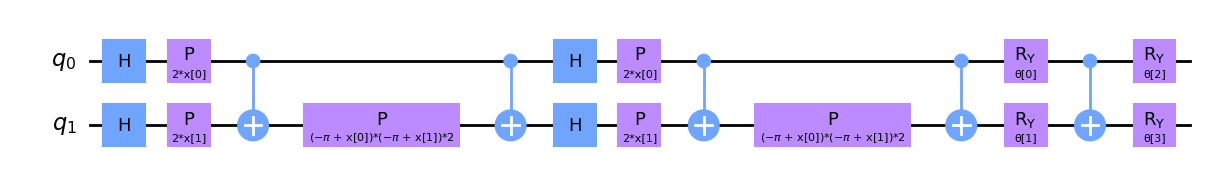

In [11]:
# 커스텀(Custom) 실진폭 안자츠(RealAmplitudes Ansatz, reps=1)로 양자 회로(Circuit) 구성
# construct a quantum circuit from the default zz_feature_map feature map and a customized real_amplitudes ansatz
qc, fm_params, anz_params = qnn_circuit(ansatz=real_amplitudes(num_inputs, reps=1))
qc.draw("mpl", style="clifford")

In [12]:
# 패리티 매핑(Parity Mapping): 비트스트링(Bitstring)의 1의 개수가 홀수면 1, 짝수면 0
# 출력 형상(Output Shape) = 2: 가능한 클래스(Class) 수
# parity maps bitstrings to 0 or 1
def parity(x):
    return "{:b}".format(x).count("1") % 2


output_shape = 2  # corresponds to the number of classes, possible outcomes of the (parity) mapping.

In [13]:
# 상태 벡터 샘플러(StatevectorSampler) 생성 및 SamplerQNN 인스턴스화
from qiskit.primitives import StatevectorSampler as Sampler

sampler = Sampler()
# construct QNN
sampler_qnn = SamplerQNN(
    circuit=qc,
    input_params=fm_params,
    weight_params=anz_params,
    interpret=parity,
    output_shape=output_shape,
    sampler=sampler,
)

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


In [14]:
# SamplerQNN 기반 분류기(Classifier) 구성
# COBYLA 최적화기(Optimizer), 최대 반복 횟수(Max Iterations) = 30
# construct classifier
sampler_classifier = NeuralNetworkClassifier(
    neural_network=sampler_qnn, optimizer=COBYLA(maxiter=30), callback=callback_graph
)

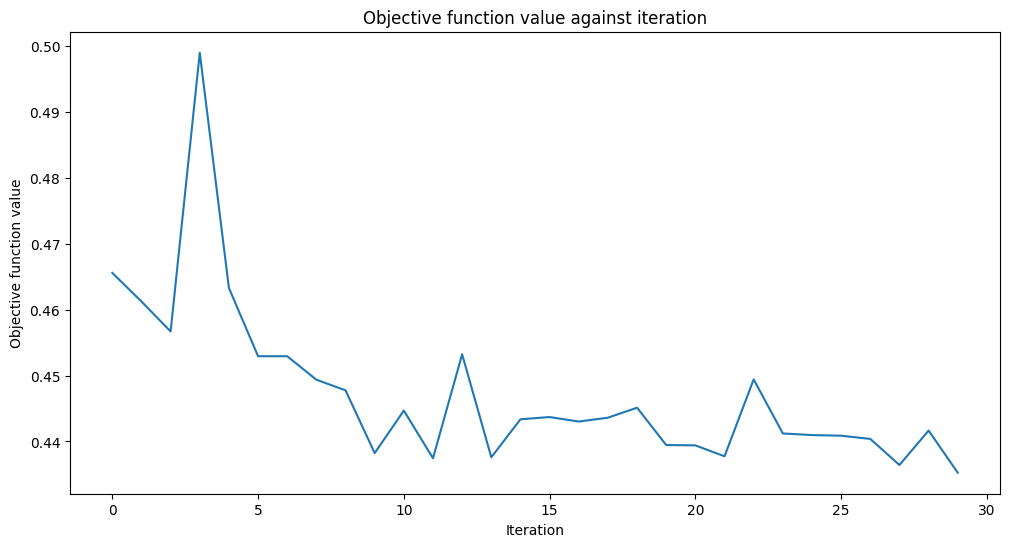

0.6

In [15]:
# 목적 함수(Objective Function) 값 히스토리 초기화
# 분류기(Classifier)를 데이터에 학습(Fitting) — 레이블(Label)은 {0, 1} 형식 사용
# 분류기(Classifier) 정확도(Accuracy) 평가
# create empty array for callback to store evaluations of the objective function
objective_func_vals = []
plt.rcParams["figure.figsize"] = (12, 6)

# fit classifier to data
sampler_classifier.fit(X, y01)

# return to default figsize
plt.rcParams["figure.figsize"] = (6, 4)

# score classifier
sampler_classifier.score(X, y01)

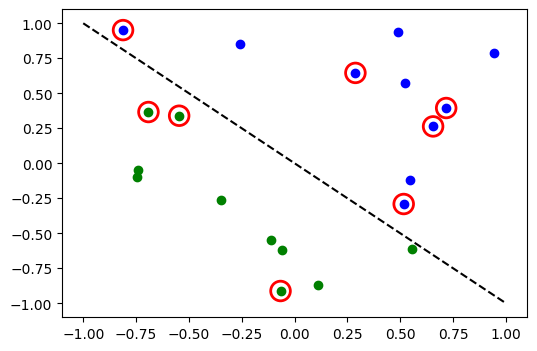

In [16]:
# 예측(Prediction) 수행 및 결과 시각화(Visualization)
# 빨간색 원 = 오분류(Misclassified)된 샘플(Sample)
# evaluate data points
y_predict = sampler_classifier.predict(X)

# plot results
# red == wrongly classified
for x, y_target, y_p in zip(X, y01, y_predict):
    if y_target == 1:
        plt.plot(x[0], x[1], "bo")
    else:
        plt.plot(x[0], x[1], "go")
    if y_target != y_p:
        plt.scatter(x[0], x[1], s=200, facecolors="none", edgecolors="r", linewidths=2)
plt.plot([-1, 1], [1, -1], "--", color="black")
plt.show()

마찬가지로 모델이 학습(trained)된 후에는 가중치(weights)를 살펴볼 수 있다. 안자츠(ansatz)에서 `reps=1`을 명시적으로 설정했으므로 이전 모델보다 적은 매개변수를 볼 수 있다.

In [17]:
# 학습된 SamplerQNN 분류기(Classifier)의 가중치(Weight) 확인
sampler_classifier.weights

array([ 0.72495182,  1.30218107, -0.97441724, -0.45324003])

### 변분 양자 분류기(`VQC`)

`VQC`는 `SamplerQNN`을 가진 `NeuralNetworkClassifier`의 특수한 변형(variant)이다. 비트 문자열에서 분류로의 매핑을 위해 패리티(parity) 매핑(또는 여러 클래스로의 확장)을 적용하여 확률(probability) 벡터를 얻고, 이는 원-핫 인코딩(one-hot encoded) 결과로 해석된다. 기본적으로 이는 원-핫 인코딩(one-hot encoded) 형식의 레이블(labels)을 예상하고 그 형식으로 예측을 반환하는 `CrossEntropyLoss` 함수를 적용한다.

In [18]:
# ZZ 특성 맵(ZZ Feature Map), 실진폭 안자츠(RealAmplitudes Ansatz) 생성
# 변분 양자 분류기(Variational Quantum Classifier, VQC) 구성 — 교차 엔트로피 손실(Cross Entropy Loss) 사용
# construct feature map, ansatz, and optimizer
feature_map = zz_feature_map(num_inputs)
ansatz = real_amplitudes(num_inputs, reps=1)

# construct variational quantum classifier
vqc = VQC(
    feature_map=feature_map,
    ansatz=ansatz,
    loss="cross_entropy",
    optimizer=COBYLA(maxiter=30),
    callback=callback_graph,
    sampler=sampler,
)

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


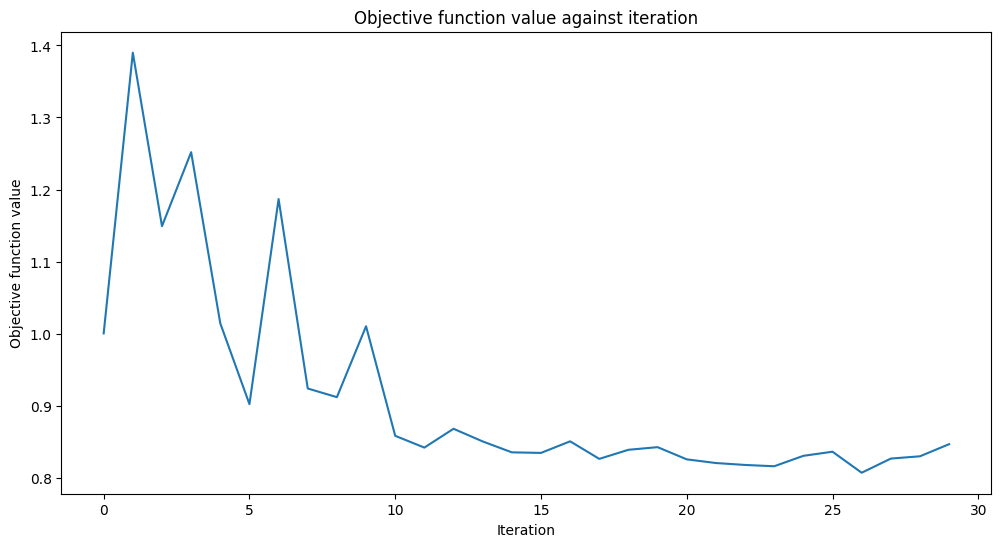

0.8

In [19]:
# 목적 함수(Objective Function) 값 히스토리 초기화
# VQC를 원-핫 인코딩(One-Hot Encoding) 레이블로 학습(Fitting)
# 변분 양자 분류기(VQC) 정확도(Accuracy) 평가
# create empty array for callback to store evaluations of the objective function
objective_func_vals = []
plt.rcParams["figure.figsize"] = (12, 6)

# fit classifier to data
vqc.fit(X, y_one_hot)

# return to default figsize
plt.rcParams["figure.figsize"] = (6, 4)

# score classifier
vqc.score(X, y_one_hot)

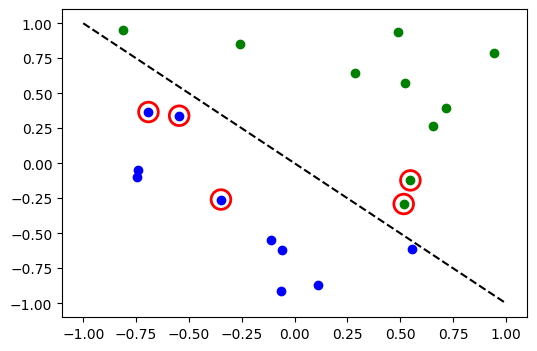

In [20]:
# 예측(Prediction) 수행 및 결과 시각화(Visualization)
# 빨간색 원 = 오분류(Misclassified)된 샘플(Sample)
# evaluate data points
y_predict = vqc.predict(X)

# plot results
# red == wrongly classified
for x, y_target, y_p in zip(X, y_one_hot, y_predict):
    if y_target[0] == 1:
        plt.plot(x[0], x[1], "bo")
    else:
        plt.plot(x[0], x[1], "go")
    if not np.all(y_target == y_p):
        plt.scatter(x[0], x[1], s=200, facecolors="none", edgecolors="r", linewidths=2)
plt.plot([-1, 1], [1, -1], "--", color="black")
plt.show()

### `VQC`를 이용한 다중 클래스(Multiple classes)
이 섹션에서는 세 개의 클래스(class) 샘플(samples)을 포함하는 인공 데이터셋(artificial dataset)을 생성하고 이 데이터셋을 분류하도록 모델을 학습하는 방법을 보여준다. 이 예제는 기계 학습에서 더 흥미로운 문제들을 어떻게 다루는지 보여준다. 물론 짧은 학습 시간을 위해 작은 데이터셋(tiny dataset)을 준비한다. SciKit-Learn에서 `make_classification`을 사용하여 데이터셋을 생성한다. 데이터셋에는 10개의 샘플(samples)이 있고 2개의 특성(features)이 있다. 즉, 데이터셋을 좋은 그래프로 표현할 수 있으며 중복되는 특성(redundant features)은 없다. 이런 특성들은 다른 특성(features)의 조합으로 생성된다. 또한 데이터셋에는 3개의 서로 다른 클래스가 있고 각 클래스는 한 종류의 중심점(centroid)을 가지며 클래스 분리(class separation)를 `2.0`으로 설정했는데, 이는 기본값 `1.0`에서 약간 증가한 값으로 분류 문제를 더 쉽게 만든다.

데이터셋이 생성되면 특성(features)을 `[0, 1]` 범위로 스케일링한다.

In [21]:
# 사이킷런(Scikit-learn)의 make_classification으로 3클래스(Class) 인공 데이터셋(Synthetic Dataset) 생성
# n_features=2, n_classes=3, class_sep=2.0
# 최솟값-최댓값 스케일러(MinMaxScaler)로 [0, 1] 범위 정규화(Normalization)
from sklearn.datasets import make_classification
from sklearn.preprocessing import MinMaxScaler

X, y = make_classification(
    n_samples=10,
    n_features=2,
    n_classes=3,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=2.0,
    random_state=algorithm_globals.random_seed,
)
X = MinMaxScaler().fit_transform(X)

우리의 데이터셋이 어떻게 보이는지 확인해본다.

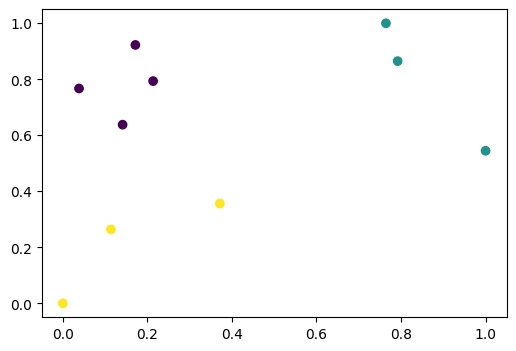

In [22]:
# 다중 클래스(Multi-class) 데이터셋(Dataset) 산점도(Scatter Plot) 시각화
plt.scatter(X[:, 0], X[:, 1], c=y)

또한 레이블(labels)을 변환하고 범주형(categorical)으로 만든다.

In [23]:
# 숫자 레이블(Numeric Label)을 문자 레이블(Categorical Label)로 변환: 0→'A', 1→'B', 2→'C'
y_cat = np.empty(y.shape, dtype=str)
y_cat[y == 0] = "A"
y_cat[y == 1] = "B"
y_cat[y == 2] = "C"
print(y_cat)

['A' 'A' 'B' 'C' 'C' 'A' 'B' 'B' 'A' 'C']


이전 예제와 유사하게 `VQC`의 인스턴스를 생성하지만 이 경우 최소한의 매개변수 집합을 전달한다. 특성 맵(feature map)과 안자츠(ansatz) 대신 데이터셋의 특성(feature) 개수와 같은 큐비트(qubits) 개수, 학습 시간을 줄이기 위해 반복 횟수가 적은 최적화기(optimizer), 양자 인스턴스(quantum instance), 진행 상황을 관찰하기 위한 콜백 함수를 전달한다.

In [24]:
# 3-클래스 분류용 변분 양자 분류기(VQC) 생성 — 최소 매개변수(Parameter) 설정으로 구성
vqc = VQC(
    num_qubits=2,
    optimizer=COBYLA(maxiter=30),
    callback=callback_graph,
    sampler=sampler,
)

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


이전 예제들과 동일한 방식으로 학습(training) 과정을 시작한다.

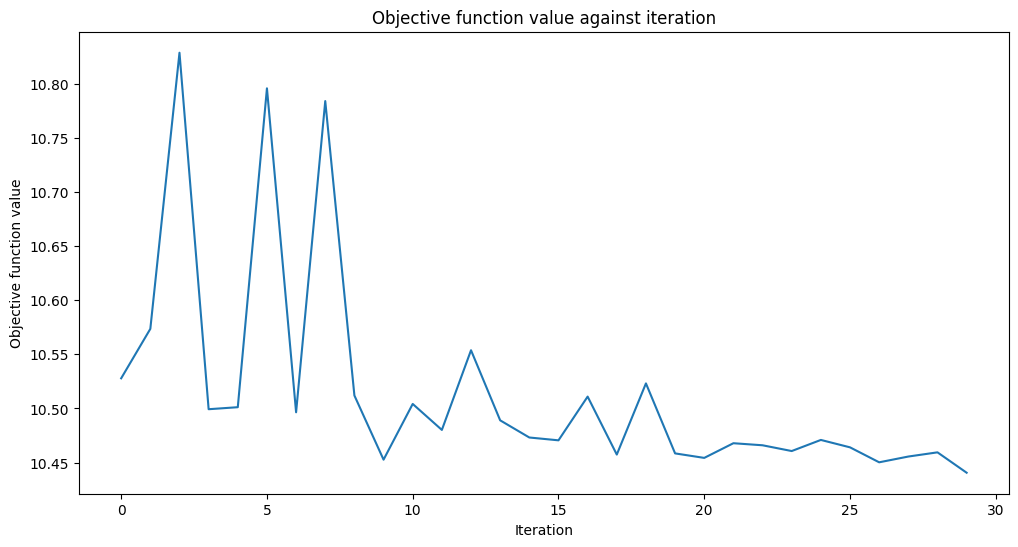

0.4

In [25]:
# 목적 함수(Objective Function) 값 히스토리 초기화
# 다중 클래스(Multi-class) VQC를 범주형 레이블(Categorical Label)로 학습(Fitting)
# 변분 양자 분류기(VQC) 정확도(Accuracy) 평가
# create empty array for callback to store evaluations of the objective function
objective_func_vals = []
plt.rcParams["figure.figsize"] = (12, 6)

# fit classifier to data
vqc.fit(X, y_cat)

# return to default figsize
plt.rcParams["figure.figsize"] = (6, 4)

# score classifier
vqc.score(X, y_cat)

반복 횟수가 적음에도 불구하고 상당히 좋은 점수를 달성했다. `predict` 메서드(method)의 출력을 확인하고 그것을 실제 참값(ground truth)과 비교해보자.

In [26]:
# 예측 레이블(Predicted Label)과 실제 레이블(Ground Truth) 비교
predict = vqc.predict(X)
print(f"Predicted labels: {predict}")
print(f"Ground truth:     {y_cat}")

Predicted labels: ['B' 'A' 'B' 'A' 'A' 'B' 'B' 'B' 'B' 'B']
Ground truth:     ['A' 'A' 'B' 'C' 'C' 'A' 'B' 'B' 'A' 'C']


## 회귀(Regression)

간단한 회귀 데이터셋(dataset)을 준비하여 다음 알고리즘들을 설명한다.

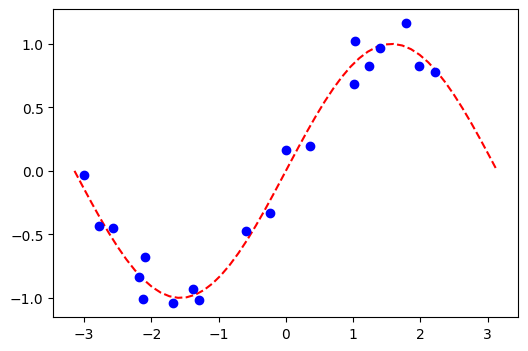

In [27]:
# 회귀(Regression) 데이터셋(Dataset) 생성
# 목표 함수(Target Function): sin(x), 노이즈(Noise) 표준편차(Standard Deviation) = 0.2
# 구간(Interval): [-π, π]
num_samples = 20
eps = 0.2
lb, ub = -np.pi, np.pi
X_ = np.linspace(lb, ub, num=50).reshape(50, 1)
f = lambda x: np.sin(x)

X = (ub - lb) * algorithm_globals.random.random([num_samples, 1]) + lb
y = f(X[:, 0]) + eps * (2 * algorithm_globals.random.random(num_samples) - 1)

plt.plot(X_, f(X_), "r--")
plt.plot(X, y, "bo")
plt.show()

### `EstimatorQNN`을 이용한 회귀

여기서는 $[-1, +1]$ 범위의 값을 반환하는 `EstimatorQNN`을 이용한 회귀로 제한한다. 더 복잡하고 또한 다차원(multi-dimensional) 모델들도 `SamplerQNN`을 기반으로 구성될 수 있지만 이것은 이 튜토리얼의 범위를 초과한다.

In [28]:
# 1큐비트(Qubit) 단순 특성 맵(Feature Map): RY 게이트(Gate)
# 1큐비트 단순 안자츠(Ansatz): RY 게이트(Gate)
# qnn_circuit으로 특성 맵과 안자츠 결합
# EstimatorQNN 인스턴스 생성
# construct simple feature map
param_x = Parameter("x")
feature_map = QuantumCircuit(1, name="fm")
feature_map.ry(param_x, 0)

# construct simple ansatz
param_y = Parameter("y")
ansatz = QuantumCircuit(1, name="vf")
ansatz.ry(param_y, 0)

# construct a circuit
qc, fm_params, anz_params = qnn_circuit(feature_map=feature_map, ansatz=ansatz)

# construct QNN
regression_estimator_qnn = EstimatorQNN(
    circuit=qc, input_params=fm_params, weight_params=anz_params, estimator=estimator
)

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


In [29]:
# 추정기 양자 신경망(EstimatorQNN) 기반 신경망 회귀기(Neural Network Regressor) 구성
# 평균 제곱 오차(Squared Error) 손실 함수(Loss Function), L-BFGS-B 최적화기(Optimizer)
# construct the regressor from the neural network
regressor = NeuralNetworkRegressor(
    neural_network=regression_estimator_qnn,
    loss="squared_error",
    optimizer=L_BFGS_B(maxiter=5),
    callback=callback_graph,
)

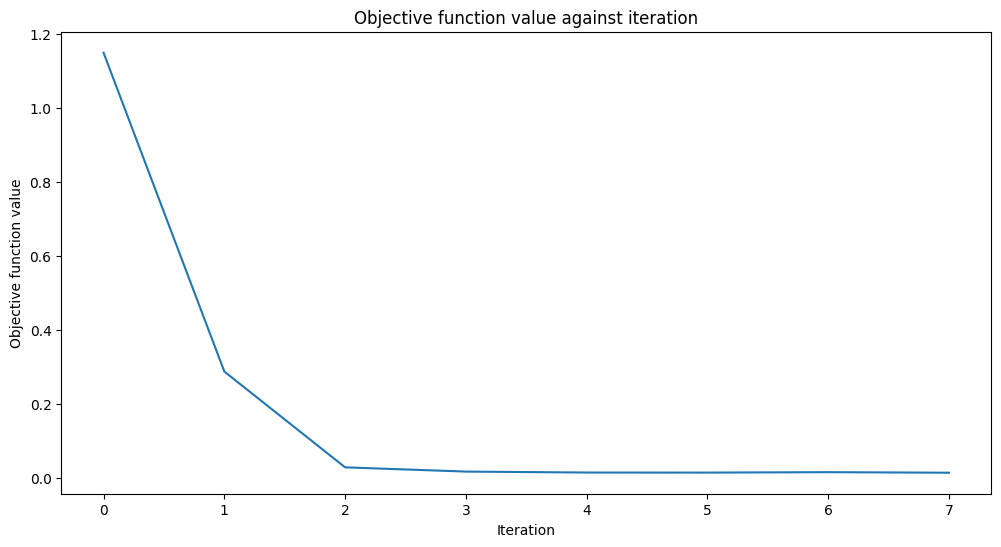

0.9769614381835028

In [30]:
# 목적 함수(Objective Function) 값 히스토리 초기화
# 회귀 모델(Regressor) 학습(Fitting)
# 결정 계수(R² Score) 평가
# create empty array for callback to store evaluations of the objective function
objective_func_vals = []
plt.rcParams["figure.figsize"] = (12, 6)

# fit to data
regressor.fit(X, y)

# return to default figsize
plt.rcParams["figure.figsize"] = (6, 4)

# score the result
regressor.score(X, y)

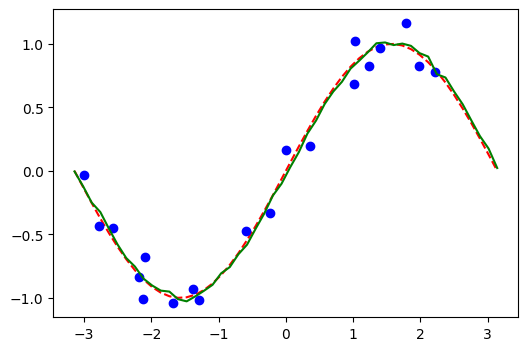

In [31]:
# 목표 함수(Target Function) 그래프(빨간 점선), 학습 데이터(Training Data, 파란 점)
# 학습된 회귀 모델(Regressor)의 예측 곡선(Fitted Curve, 초록 실선)
# plot target function
plt.plot(X_, f(X_), "r--")

# plot data
plt.plot(X, y, "bo")

# plot fitted line
y_ = regressor.predict(X_)
plt.plot(X_, y_, "g-")
plt.show()

분류 모델(classification models)과 유사하게 모델의 해당 속성(property)을 쿼리하여 학습된 가중치(trained weights)의 배열을 얻을 수 있다. 이 모델에는 위에서 정의한 `param_y`로 정의된 매개변수가 하나만 있다.

In [32]:
# 학습된 회귀 모델(Regressor)의 가중치(Weight) — param_y 1개
regressor.weights

array([-1.60069137])

### 변분 양자 회귀기(`VQR`)를 이용한 회귀

분류를 위한 `VQC`와 유사하게 `VQR`은 `EstimatorQNN`을 가진 `NeuralNetworkRegressor`의 특수한 변형(variant)이다. 기본적으로 예측과 목표 값 사이의 평균 제곱 오차(mean squared error)를 최소화하는 `L2Loss` 함수를 고려한다.

In [33]:
# L2 손실 함수(L2Loss)를 사용하는 변분 양자 회귀기(Variational Quantum Regressor, VQR) 생성
vqr = VQR(
    feature_map=feature_map,
    ansatz=ansatz,
    optimizer=L_BFGS_B(maxiter=5),
    callback=callback_graph,
    estimator=estimator,
)

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


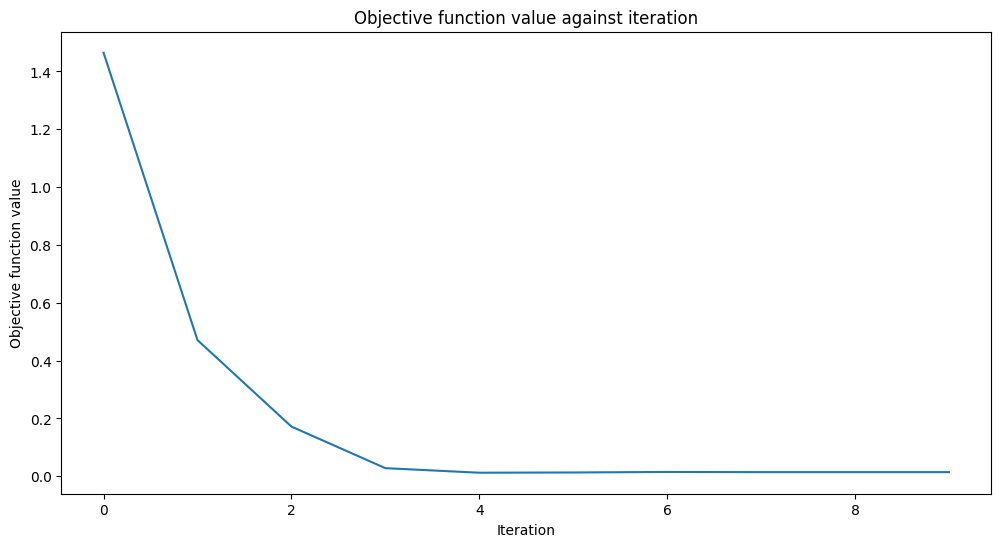

0.973355688390675

In [34]:
# 목적 함수(Objective Function) 값 히스토리 초기화
# 변분 양자 회귀기(VQR) 학습(Fitting)
# 변분 양자 회귀기(VQR) 점수(Score) 평가
# create empty array for callback to store evaluations of the objective function
objective_func_vals = []
plt.rcParams["figure.figsize"] = (12, 6)

# fit regressor
vqr.fit(X, y)

# return to default figsize
plt.rcParams["figure.figsize"] = (6, 4)

# score result
vqr.score(X, y)

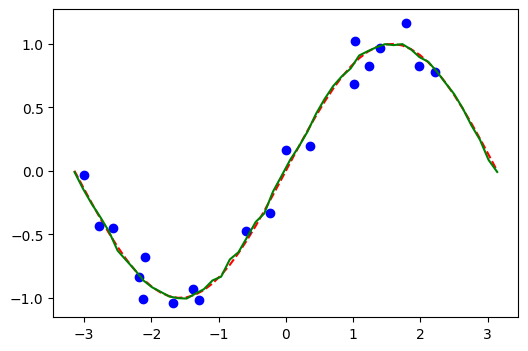

In [35]:
# 목표 함수(Target Function, 빨간 점선), 학습 데이터(Training Data, 파란 점)
# 변분 양자 회귀기(VQR)의 예측 곡선(Fitted Curve, 초록 실선)
# plot target function
plt.plot(X_, f(X_), "r--")

# plot data
plt.plot(X, y, "bo")

# plot fitted line
y_ = vqr.predict(X_)
plt.plot(X_, y_, "g-")
plt.show()

In [1]:
# 버전 정보 및 저작권을 표시한다(Display version information and copyright)
import tutorial_magics

%qiskit_version_table
%qiskit_copyright